<a href="https://colab.research.google.com/github/Lavesh789/Sales_forecasting_app/blob/main/salesforecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from google.colab import files
uploaded = files.upload()

!pip install -q openpyxl scikit-learn seaborn matplotlib

Saving Sales_Forcasting_Dataset.xlsx to Sales_Forcasting_Dataset (1).xlsx


EDA

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
df['Date'] = pd.to_datetime(df['Date'])
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Row_ID               3000 non-null   int64         
 1   Date                 3000 non-null   datetime64[ns]
 2   Product_ID           3000 non-null   object        
 3   Product_Name         3000 non-null   object        
 4   Category             3000 non-null   object        
 5   Store_ID             3000 non-null   object        
 6   Store_Location       3000 non-null   object        
 7   Units_Sold           3000 non-null   int64         
 8   Price                3000 non-null   float64       
 9   Discount_Percentage  3000 non-null   int64         
 10  Revenue              3000 non-null   float64       
 11  Promotion_Flag       3000 non-null   int64         
 12  Stock_Availability   3000 non-null   int64         
 13  Day_of_Week          3000 non-nul

,0
Row_ID,0
Date,0
Product_ID,0
Product_Name,0
Category,0
Store_ID,0
Store_Location,0
Units_Sold,0
Price,0
Discount_Percentage,0


In [25]:
print(df['Quarter'].unique())

['Q1' 'Q2' 'Q3' 'Q4']


In [26]:
print(df['Store_Location'].unique())

['Chennai' 'Delhi' 'Bengaluru' 'Mumbai']


In [27]:
print(df['Season'].unique())

['Winter' 'Spring' 'Summer' 'Autumn']


In [28]:
print(df['Sales_Channel'].unique())

['Online' 'In-Store' 'Wholesale']


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df['Date'].duplicated().sum()

np.int64(1923)

In [31]:
df['Row_ID'].duplicated().sum()

np.int64(0)

In [32]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nSummary stats:\n", df.describe())

Shape: (3000, 27)

Missing values:
 Holiday_Name    2969
dtype: int64

Summary stats:
             Row_ID                        Date   Units_Sold        Price  \
count  3000.000000                        3000  3000.000000  3000.000000   
mean   1500.500000  2024-12-25 22:29:16.800000    42.068667  2573.711019   
min       1.000000         2023-01-06 00:00:00     0.000000   201.882929   
25%     750.750000         2024-06-08 00:00:00    15.000000  1291.656025   
50%    1500.500000         2024-12-21 00:00:00    43.000000  2548.635583   
75%    2250.250000         2025-07-19 00:00:00    64.000000  3773.608720   
max    3000.000000         2026-12-25 00:00:00   121.000000  4995.614847   
std     866.169729                         NaN    29.250319  1395.352185   

       Discount_Percentage        Revenue  Promotion_Flag  Stock_Availability  \
count          3000.000000    3000.000000     3000.000000         3000.000000   
mean              7.901333   93319.937417        0.713000         

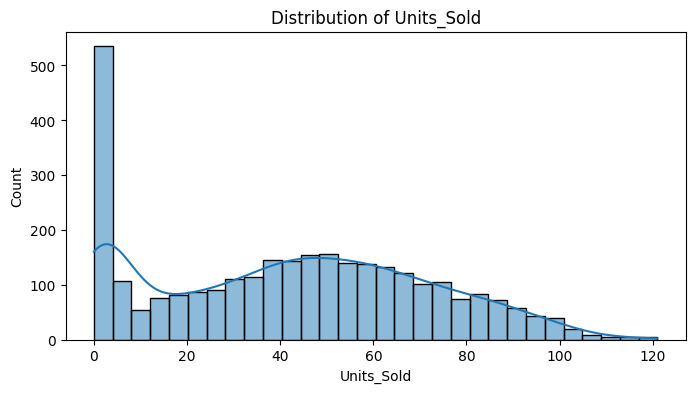

In [33]:
# Units_Sold distribution
plt.figure(figsize=(8,4))
sns.histplot(df['Units_Sold'], bins=30, kde=True)
plt.title('Distribution of Units_Sold')
plt.show()

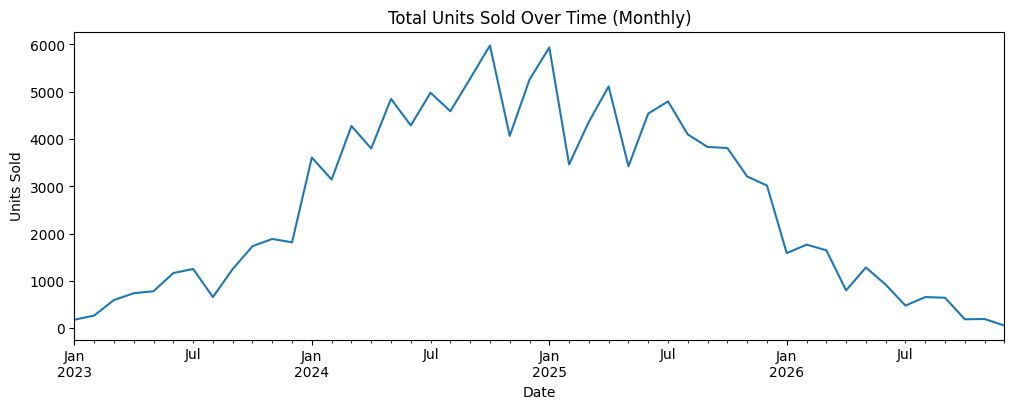

In [34]:
# Trend over time
monthly = df.groupby(df['Date'].dt.to_period('M'))['Units_Sold'].sum()
plt.figure(figsize=(12,4))
monthly.plot()
plt.title('Total Units Sold Over Time (Monthly)')
plt.ylabel('Units Sold')
plt.show()

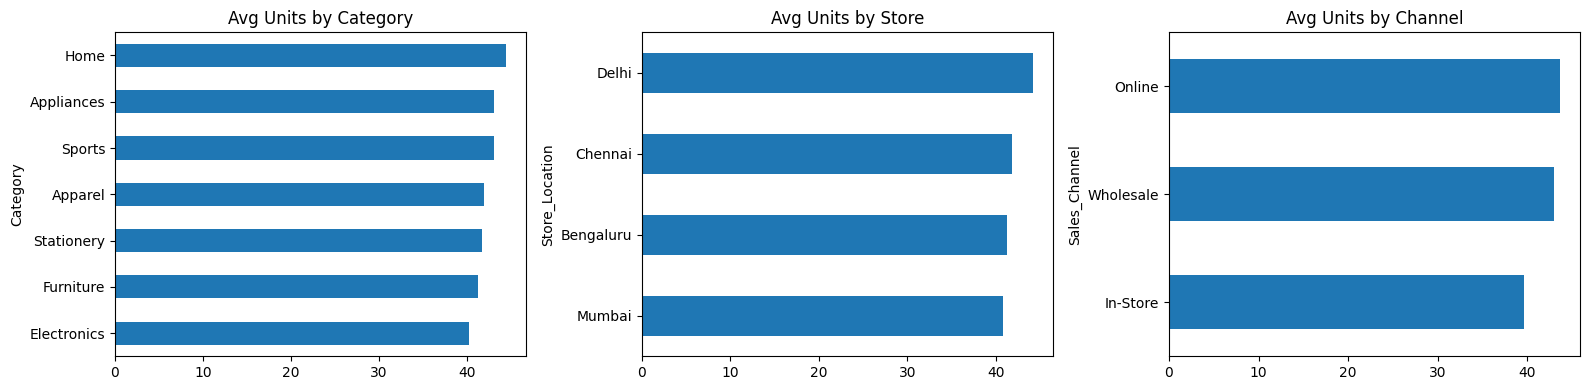

In [35]:
# Units sold by category / store / channel
fig, axes = plt.subplots(1, 3, figsize=(16,4))
df.groupby('Category')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[0], title='Avg Units by Category')
df.groupby('Store_Location')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[1], title='Avg Units by Store')
df.groupby('Sales_Channel')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=axes[2], title='Avg Units by Channel')
plt.tight_layout()
plt.show()

In [36]:
# Correlation with target
numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['Row_ID'])
corr_with_target = numeric_df.corr()['Units_Sold'].sort_values(ascending=False)
print("\nCorrelation with Units_Sold:\n", corr_with_target)


Correlation with Units_Sold:
 Units_Sold             1.000000
Stock_Availability     0.693741
Revenue                0.579453
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Is_Weekend             0.215244
Local_Event_Flag       0.153969
Holiday_Flag           0.041688
Economic_Indicator    -0.027352
Price                 -0.306506
Competitor_Price      -0.309005
Name: Units_Sold, dtype: float64


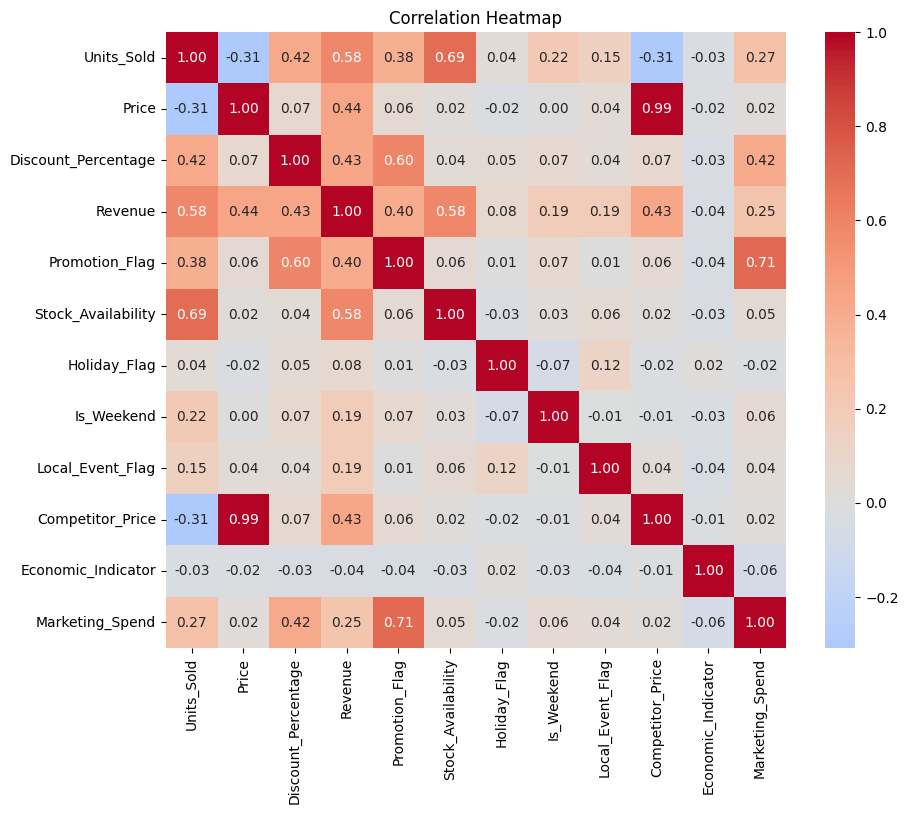

In [37]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Feature Importance

Top 15 features driving Units_Sold:
 Stock_Availability            0.480647
Discount_Percentage           0.194901
Price                         0.104461
Competitor_Price              0.092268
Promotion_Flag                0.022519
Marketing_Spend               0.019760
Is_Weekend                    0.011311
Local_Event_Flag              0.011091
Economic_Indicator            0.009209
Holiday_Flag                  0.004742
Day_of_Week_Saturday          0.003003
Weather_Clear                 0.001891
Customer_Segment_Wholesale    0.001618
Month_September               0.001510
Season_Spring                 0.001508
dtype: float64


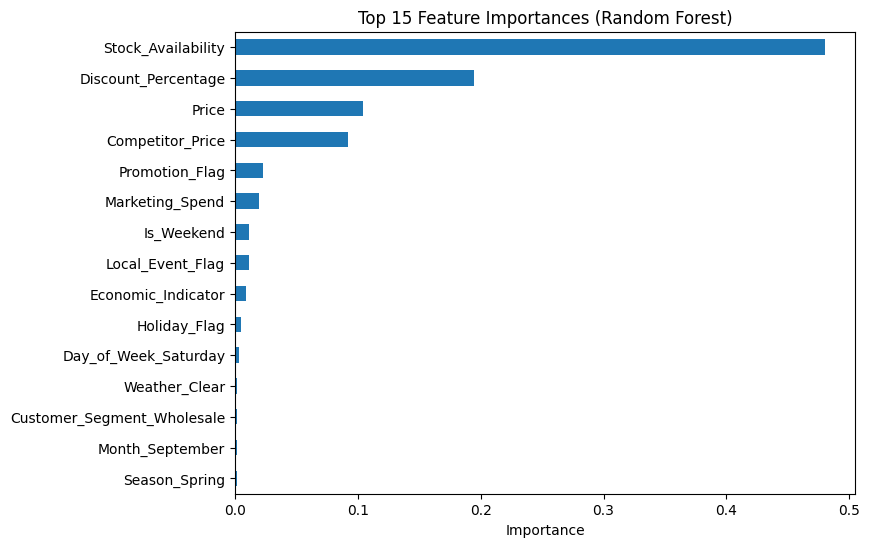

In [38]:
!pip install -q xgboost
!pip install scikit-learn
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor

target = 'Units_Sold'
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X, y)

ohe = rf_pipeline.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(rf_pipeline.named_steps['rf'].feature_importances_, index=feat_names)
importances = importances.sort_values(ascending=False)

print("Top 15 features driving Units_Sold:\n", importances.head(15))

plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()

In [39]:
print('numpy', np.__version__)
print('pandas', pd.__version__)
print('sklearn', sklearn.__version__)

numpy 2.1.3
pandas 2.2.3
sklearn 1.6.1


Build the Forecasting/Predictive Model

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))])
}

results = {}
fitted_models = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'R2': r2_score(y_test, pred)
    }
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

                        MAE       RMSE        R2
Random Forest      3.070106   4.300292  0.978231
XGBoost            3.119748   4.318620  0.978046
Gradient Boosting  4.443235   6.035009  0.957127
Linear Regression  9.393725  12.087784  0.828001



 Best model: Random Forest (R² = 0.9782)


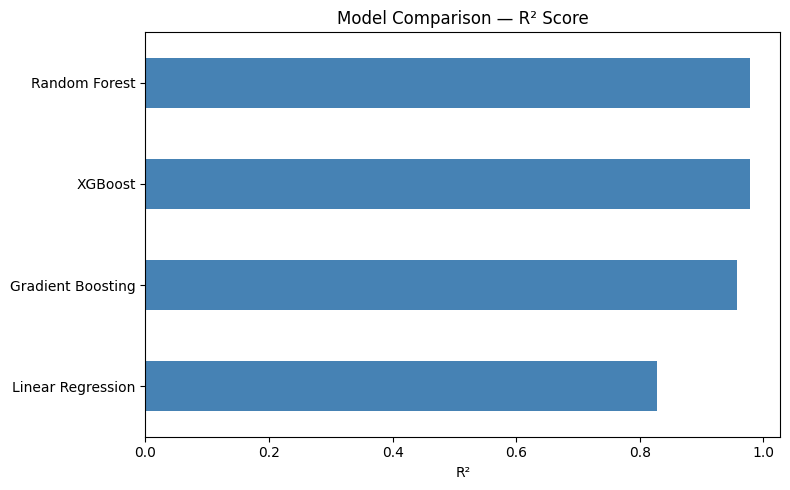

In [41]:
#Auto-select the best model
best_name = results_df['R2'].idxmax()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['R2'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — R² Score')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

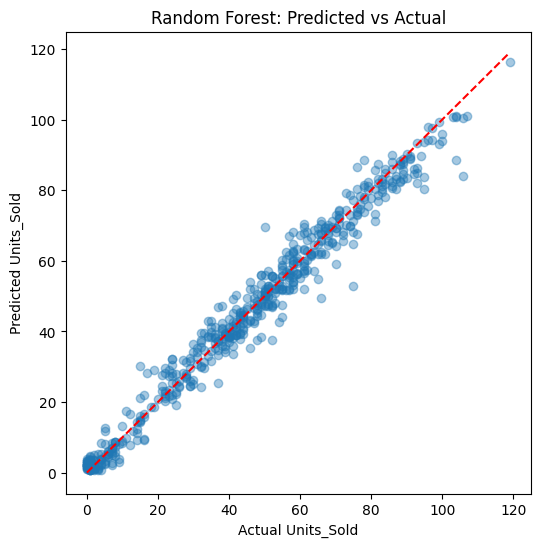

In [42]:
# Best model = Random Forest (typically). Plot predicted vs actual
best_pipe = models['Random Forest']
pred = best_pipe.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('Random Forest: Predicted vs Actual')
plt.show()

Combined Summary (EDA + Model insights together)

In [43]:
print("KEY INSIGHTS\n")
print("1. Top correlates of Units_Sold (linear):")
print(corr_with_target.drop('Units_Sold').head(5))

print("\n2. Top drivers (non-linear, Random Forest):")
print(importances.head(5))

print("\n3. Model performance:")
print(results_df)

print("\n4. Business takeaways:")
print("- Stock_Availability is the single biggest driver — stockouts are likely capping sales.")
print("- Discounting and promotions meaningfully lift Units_Sold.")
print("- Price and Competitor_Price move inversely with Units_Sold, as expected.")
print("- Economic_Indicator and Holiday_Flag have minimal individual predictive power here.")

KEY INSIGHTS

1. Top correlates of Units_Sold (linear):
Stock_Availability     0.693741
Revenue                0.579453
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Name: Units_Sold, dtype: float64

2. Top drivers (non-linear, Random Forest):
Stock_Availability     0.480647
Discount_Percentage    0.194901
Price                  0.104461
Competitor_Price       0.092268
Promotion_Flag         0.022519
dtype: float64

3. Model performance:
                        MAE       RMSE        R2
Random Forest      3.070106   4.300292  0.978231
XGBoost            3.119748   4.318620  0.978046
Gradient Boosting  4.443235   6.035009  0.957127
Linear Regression  9.393725  12.087784  0.828001

4. Business takeaways:
- Stock_Availability is the single biggest driver — stockouts are likely capping sales.
- Discounting and promotions meaningfully lift Units_Sold.
- Price and Competitor_Price move inversely with Units_Sold, as expected.
- Economic_Indicat

Feature Engineering

In [44]:
import pandas as pd
import numpy as np

df = df.sort_values(['Product_ID', 'Store_ID', 'Date']).reset_index(drop=True)

df['Year'] = df['Date'].dt.year
df['Day'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.dayofyear
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['Month_Num'] = df['Date'].dt.month
df['DayOfWeek_Num'] = df['Date'].dt.dayofweek

#Cyclical encoding (so Dec and Jan, or Sun and Mon, are "close" to a model)
df['Month_sin'] = np.sin(2 * np.pi * df['Month_Num'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month_Num'] / 12)
df['DOW_sin'] = np.sin(2 * np.pi * df['DayOfWeek_Num'] / 7)
df['DOW_cos'] = np.cos(2 * np.pi * df['DayOfWeek_Num'] / 7)

#Price-related features
df['Price_Diff_vs_Competitor'] = df['Price'] - df['Competitor_Price']
df['Price_Ratio_vs_Competitor'] = df['Price'] / df['Competitor_Price']
df['Discounted_Price'] = df['Price'] * (1 - df['Discount_Percentage'] / 100)
df['Discount_Amount'] = df['Price'] - df['Discounted_Price']

#Marketing efficiency
df['Marketing_Spend_per_Unit_Price'] = df['Marketing_Spend'] / df['Price']

#Interaction features (combined effects)
df['Promo_and_Weekend'] = df['Promotion_Flag'] * df['Is_Weekend']
df['Promo_and_Holiday'] = df['Promotion_Flag'] * df['Holiday_Flag']
df['InStock_and_Promo'] = df['Stock_Availability'] * df['Promotion_Flag']

#Lag & rolling features per Product + Store (time-series signal)
grp = df.groupby(['Product_ID', 'Store_ID'])
df['Units_Sold_Lag1'] = grp['Units_Sold'].shift(1)
df['Units_Sold_Lag7'] = grp['Units_Sold'].shift(7)
df['Units_Sold_RollMean_4'] = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
df['Units_Sold_RollStd_4']  = grp['Units_Sold'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).std())

# Fill lag/rolling NaNs (first record(s) of each product/store group) with that group's mean
for c in ['Units_Sold_Lag1', 'Units_Sold_Lag7', 'Units_Sold_RollMean_4', 'Units_Sold_RollStd_4']:
    df[c] = df[c].fillna(grp['Units_Sold'].transform('mean'))

#Holiday flag consolidation
df['Has_Holiday_Name'] = df['Holiday_Name'].notna().astype(int)

print("New shape:", df.shape)
print("New columns added:", df.shape[1] - 27)
df[['Date','Product_ID','Store_ID','Units_Sold','Units_Sold_Lag1','Units_Sold_Lag7','Units_Sold_RollMean_4']].head(10)

New shape: (3000, 50)
New columns added: 23


,Date,Product_ID,Store_ID,Units_Sold,Units_Sold_Lag1,Units_Sold_Lag7,Units_Sold_RollMean_4
0,2023-04-08,P001,S01,51,42.566929,42.566929,42.566929
1,2023-05-19,P001,S01,33,51.000000,42.566929,51.000000
2,2023-07-16,P001,S01,23,33.000000,42.566929,42.000000
3,2023-07-22,P001,S01,22,23.000000,42.566929,35.666667
4,2023-09-23,P001,S01,18,22.000000,42.566929,32.250000
5,2023-12-13,P001,S01,24,18.000000,42.566929,24.000000
6,2023-12-31,P001,S01,36,24.000000,42.566929,21.750000
7,2024-01-20,P001,S01,47,36.000000,51.000000,25.000000
8,2024-01-26,P001,S01,44,47.000000,33.000000,31.250000
9,2024-02-07,P001,S01,1,44.000000,23.000000,37.750000


Model with Engineered Features

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

target = 'Units_Sold'
# Drop identifiers/leakage, and raw Month_Num/DayOfWeek_Num (replaced by sin/cos versions)
drop_cols = ['Row_ID', 'Date', 'Units_Sold', 'Revenue', 'Holiday_Name',
             'Month_Num', 'DayOfWeek_Num']
X = df.drop(columns=drop_cols)
y = df[target]

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
], remainder='passthrough')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': Pipeline([('prep', preprocessor), ('model', LinearRegression())]),
    'Random Forest': Pipeline([('prep', preprocessor),('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))]),
    'XGBoost': Pipeline([('prep', preprocessor),('model', XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,subsample=0.8, colsample_bytree=0.8,random_state=42, n_jobs=-1))]),
     'Gradient Boosting': Pipeline([('prep', preprocessor),('model', GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42))])
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results[name] = {
        'MAE': mean_absolute_error(y_test, pred),
        'RMSE': mean_squared_error(y_test, pred) ** 0.5,
        'R2': r2_score(y_test, pred)
    }

results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
print(results_df)

                        MAE       RMSE        R2
XGBoost            3.695570   4.965687  0.971494
Random Forest      3.769128   5.174714  0.969043
Gradient Boosting  4.718728   6.277199  0.954447
Linear Regression  8.037200  10.091895  0.882259



 Best model: XGBoost (R² = 0.9715)


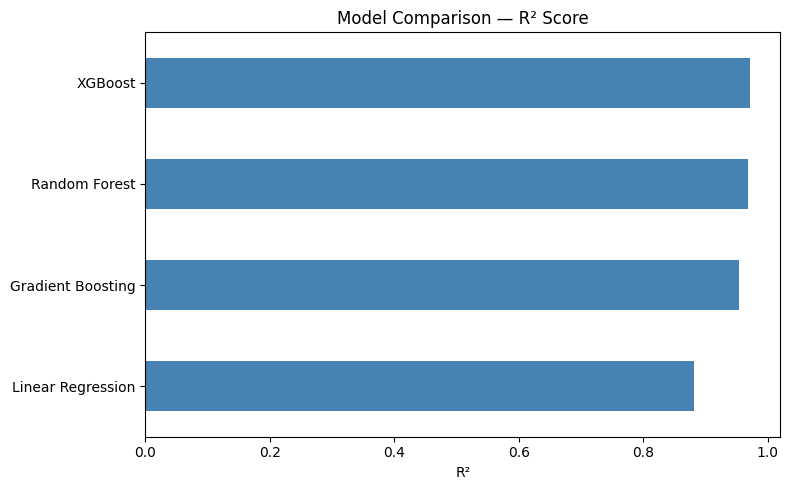

In [46]:
#Auto-select the best model
best_name = results_df['R2'].idxmax()
best_pipe = fitted_models[best_name]
print(f"\n Best model: {best_name} (R² = {results_df.loc[best_name, 'R2']:.4f})")

# Bar chart comparing all 4
plt.figure(figsize=(8,5))
results_df['R2'].sort_values().plot(kind='barh', color='steelblue')
plt.title('Model Comparison — R² Score')
plt.xlabel('R²')
plt.tight_layout()
plt.show()

In [47]:
# Refit feature importance on the richer feature set
best_pipe = models['XGBoost']
ohe = best_pipe.named_steps['prep'].named_transformers_['cat']
feat_names = list(ohe.get_feature_names_out(cat_cols)) + num_cols
importances = pd.Series(best_pipe.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False)
print("\nTop 15 features:\n", importances.head(15))


Top 15 features:
 InStock_and_Promo       0.613882
Stock_Availability      0.118723
Promotion_Flag          0.049131
Discounted_Price        0.031987
Discount_Percentage     0.017913
Promo_and_Holiday       0.017674
Promo_and_Weekend       0.015701
Competitor_Price        0.010153
Local_Event_Flag        0.008416
Is_Weekend              0.007823
Price                   0.006174
Holiday_Flag            0.005430
Day_of_Week_Saturday    0.004621
Day_of_Week_Sunday      0.004582
Discount_Amount         0.003944
dtype: float32


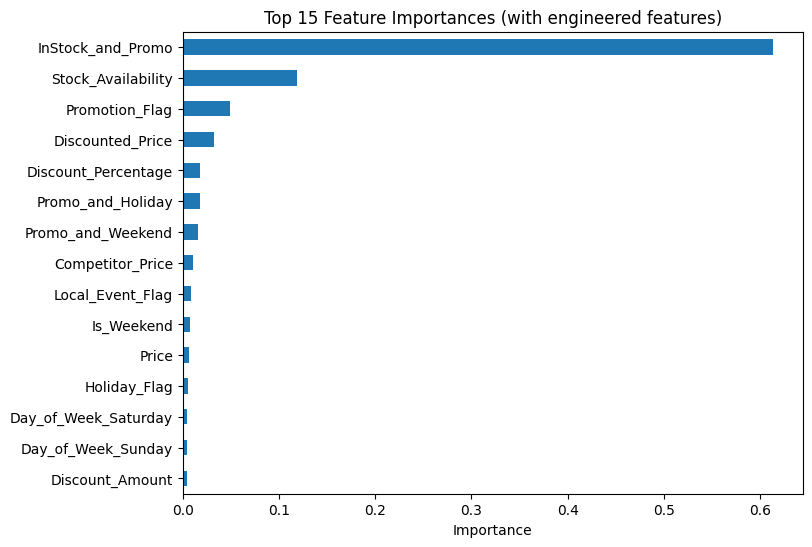

In [48]:
plt.figure(figsize=(8,6))
importances.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Feature Importances (with engineered features)')
plt.xlabel('Importance')
plt.show()

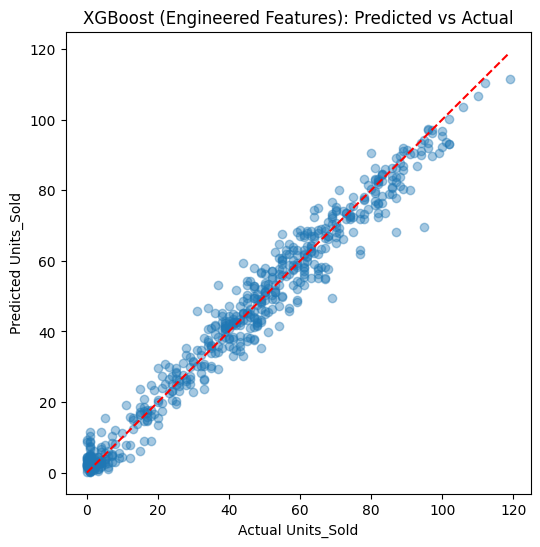

In [49]:
# Predicted vs actual
pred = best_pipe.predict(X_test)
plt.figure(figsize=(6,6))
plt.scatter(y_test, pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Units_Sold')
plt.ylabel('Predicted Units_Sold')
plt.title('XGBoost (Engineered Features): Predicted vs Actual')
plt.show()

Hyperparameter Tuning & Final Model

In [50]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
import joblib

pipe = Pipeline([('prep', preprocessor), ('model', XGBRegressor(random_state=42, n_jobs=-1))])

param_dist = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [3, 6, 9],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0]
}

search = RandomizedSearchCV(pipe, param_dist, n_iter=5, cv=3, scoring='r2', random_state=42, n_jobs=-1)
search.fit(X_train, y_train)

print("Best params:", search.best_params_)
best_model = search.best_estimator_

pred = best_model.predict(X_test)
print("Tuned MAE:", mean_absolute_error(y_test, pred))
print("Tuned RMSE:", mean_squared_error(y_test, pred) ** 0.5)
print("Tuned R2:", r2_score(y_test, pred))

# Save the final model for later reuse
joblib.dump(best_model, 'sales_forecast_model.pkl')
print("Model saved as sales_forecast_model.pkl")

# To reload later: best_model = joblib.load('sales_forecast_model.pkl')

Best params: {'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 9, 'model__learning_rate': 0.01}
Tuned MAE: 4.091211318969727
Tuned RMSE: 5.3981267505646
Tuned R2: 0.9663125872612
Model saved as sales_forecast_model.pkl


Generate Predictions & Package for Business Use

In [51]:
#Reusable prediction function
def predict_units_sold(new_data: pd.DataFrame, model_path='sales_forecast_model.pkl'):

    model = joblib.load(model_path)
    return model.predict(new_data)

# Quick sanity check on a few held-out rows
sample = X_test.iloc[:5]
print("Sample predictions:", predict_units_sold(sample))

Sample predictions: [56.94504  34.208828 62.52939   4.894013 56.805553]


In [52]:
#Full test-set results table, with error column
test_results = X_test.copy()
test_results['Actual_Units_Sold'] = y_test.values
test_results['Predicted_Units_Sold'] = best_model.predict(X_test).round(1)
test_results['Abs_Error'] = (test_results['Actual_Units_Sold'] - test_results['Predicted_Units_Sold']).abs()

test_results.to_excel('sales_forecast_predictions.xlsx', index=False)
print("Saved: sales_forecast_predictions.xlsx —", test_results.shape)

Saved: sales_forecast_predictions.xlsx — (600, 46)


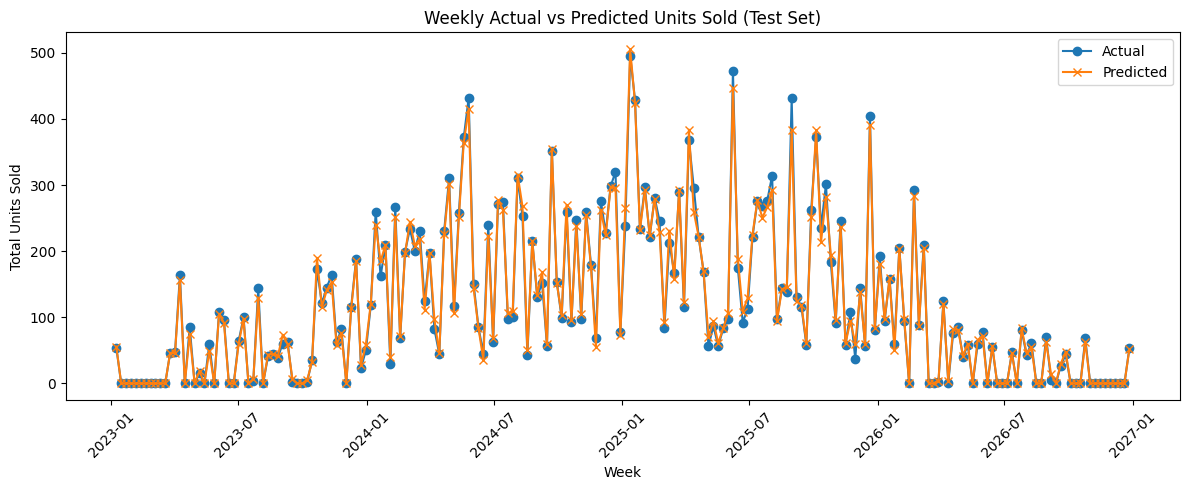

In [53]:
#Actual vs Predicted over time (weekly aggregate, for a trend chart)
comp = df.loc[X_test.index, ['Date']].copy()
comp['Actual'] = y_test.values
comp['Predicted'] = best_model.predict(X_test)
comp = comp.sort_values('Date')

weekly = comp.set_index('Date').resample('W').sum(numeric_only=True)

plt.figure(figsize=(12, 5))
plt.plot(weekly.index, weekly['Actual'], label='Actual', marker='o')
plt.plot(weekly.index, weekly['Predicted'], label='Predicted', marker='x')
plt.title('Weekly Actual vs Predicted Units Sold (Test Set)')
plt.xlabel('Week')
plt.ylabel('Total Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Download the files from Colab
#from google.colab import files
#files.download('sales_forecast_model.pkl')
#files.download('sales_forecast_predictions.xlsx')